# Greedy policy improvement from the critic

The idea behind this improvement and the results are presented in more detail in the report. Put simply, in RL terminology, let $(\mathcal{A}, \mathcal{S})$ denote the action and state spaces. From the normalization of $\mathcal{S}$ by the average size, together with the upper and lower bounds for the inventory, we can safely assume that the state space is discrete.

To explore this discretization further, we implement in this notebook a *greedy policy* by discretizing $\mathcal{A}$ and, at each time $t$, choosing an action (that is, a probability) that maximizes the expected immediate reward.

This method should be faster than approximating the optimal policy with a neural network and is memory-feasible. However, for $d \geq 2$, it is expected to perform poorly because it ignores cross-bond interactions.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
from pathlib import Path

os.chdir("..")

from config.constants import *
from core.models import *
from core.rollout import rollout
from training.critic_update import update_critic_td
from training.pretraining_actor import myopic_probs
from core.SimulationEnvironment import *
from training.pretraining_critic import *
from utils import *
device_used = "cpu"
torch.manual_seed(42)
np.random.seed(42)


In [2]:
class TableActor1D(nn.Module):
    def __init__(self, i, lb_i, ub_i, size_i, init_p=0.5):
        super().__init__()
        self.i = int(i)
        self.lb_i = float(lb_i)
        self.ub_i = float(ub_i)
        self.size_i = float(size_i)
        self.n_states = int(round((self.ub_i - self.lb_i) / self.size_i)) + 1
        self.register_buffer("table", torch.full((self.n_states,), float(init_p), dtype=torch.float32))

    def forward(self, x):
        xi = x[:, self.i]
        q_signed = xi * self.size_i
        idx = torch.round((q_signed - self.lb_i) / self.size_i).long()
        idx = torch.clamp(idx, 0, self.n_states - 1)
        return self.table[idx].unsqueeze(1)

    def set_table(self, values):
        v = torch.as_tensor(values, dtype=torch.float32, device=self.table.device).reshape(self.n_states)
        self.table.copy_(v)


In [3]:
def build_index_bounds(lb, ub, avg_sizes):
    lb = np.asarray(lb, dtype=float).reshape(-1)
    ub = np.asarray(ub, dtype=float).reshape(-1)
    avg_sizes = np.asarray(avg_sizes, dtype=float).reshape(-1)
    low_idx = np.rint(lb / avg_sizes).astype(np.int64)
    high_idx = np.rint(ub / avg_sizes).astype(np.int64)
    return low_idx, high_idx


def sample_discrete_starts(n_samples, low_idx, high_idx, avg_sizes, rng):
    d = len(low_idx)
    idx = np.empty((n_samples, d), dtype=np.int64)
    for j in range(d):
        idx[:, j] = rng.integers(low_idx[j], high_idx[j] + 1, size=n_samples)
    return idx.astype(np.float32) * np.asarray(avg_sizes, dtype=np.float32).reshape(1, -1)


In [4]:
def greedy_refresh_actor_1d_from_critic(
    actor_i,
    critic,
    market,
    i,
    Sigma,
    avg_sizes,
    lb,
    ub,
    p_grid=None,
    r=RF,
    device="cpu",
):
    critic = critic.to(device)

    if p_grid is None:
        p_grid = torch.linspace(NU, 1.0 - NU, 101, device=device)
    else:
        p_grid = torch.as_tensor(p_grid, dtype=torch.float32, device=device)

    avg_sizes = np.asarray(avg_sizes, dtype=np.float32)
    size_i = float(avg_sizes[i])

    q_grid = actor_i.lb_i + actor_i.size_i * np.arange(actor_i.n_states, dtype=np.float32)
    n = actor_i.n_states
    d = len(avg_sizes)

    S = np.zeros((n, d), dtype=np.float32)
    S[:, i] = q_grid

    S_trade = S.copy()
    S_trade[:, i] = np.clip(S_trade[:, i] + size_i, actor_i.lb_i, actor_i.ub_i)

    S_t = torch.as_tensor(S / avg_sizes.reshape(1, -1), dtype=torch.float32, device=device)
    S_trade_t = torch.as_tensor(S_trade / avg_sizes.reshape(1, -1), dtype=torch.float32, device=device)

    S_raw_t = torch.as_tensor(S, dtype=torch.float32, device=device)
    S_trade_raw_t = torch.as_tensor(S_trade, dtype=torch.float32, device=device)
    Sigma_t = torch.as_tensor(np.asarray(Sigma, dtype=np.float32), dtype=torch.float32, device=device)

    lambdas = np.asarray(market.lambda_RFQs, dtype=np.float32).reshape(-1)
    Lambda = 2.0 * float(lambdas.sum())
    denom = float(r) + Lambda
    gamma_rl = Lambda / denom

    with torch.no_grad():
        V_q = critic(S_t)
        V_trade = critic(S_trade_t)

        if V_q.dim() == 2:
            V_q = V_q[:, 0]
        if V_trade.dim() == 2:
            V_trade = V_trade[:, 0]

        psi_q = 0.5 * float(GAMMA) * torch.sqrt(torch.einsum("bi,ij,bj->b", S_raw_t, Sigma_t, S_raw_t))
        psi_trade = 0.5 * float(GAMMA) * torch.sqrt(torch.einsum("bi,ij,bj->b", S_trade_raw_t, Sigma_t, S_trade_raw_t))

        delta_grid = torch.as_tensor(
            np.asarray(market.inv_f(i, p_grid.detach().cpu().numpy()), dtype=np.float32),
            dtype=torch.float32,
            device=device,
        )

        trade_term = size_i * delta_grid.unsqueeze(0) - psi_trade.unsqueeze(1) / denom + gamma_rl * V_trade.unsqueeze(1)
        stay_term = -psi_q.unsqueeze(1) / denom + gamma_rl * V_q.unsqueeze(1)

        scores = p_grid.unsqueeze(0) * trade_term + (1.0 - p_grid.unsqueeze(0)) * stay_term
        best_idx = torch.argmax(scores, dim=1)
        p_star = p_grid[best_idx]

    actor_i.set_table(p_star)

    return {
        "q_grid": q_grid,
        "p_star": p_star.detach().cpu().numpy(),
    }


In [5]:
def train_final_greedy(
    actors,
    critic,
    market,
    r,
    Sigma,
    nb_steps,
    avg_sizes,
    long_horizon=1000,
    nb_short_rollouts=10,
    short_horizon=100,
    critic_batch_size=70,
    n_epochs_critic=1,
    LB_init=None,
    UB_init=None,
    LB_max=None,
    UB_max=None,
    critic_lr=1e-3,
    update_risk_after=500,
    p_grid=None,
    seed=42,
    device=None,
):
    rng = np.random.default_rng(seed)

    if isinstance(actors, dict):
        d = len(actors)
        policy = [actors[i] for i in range(d)]
    else:
        d = len(actors)
        policy = list(actors)

    critic_opt = torch.optim.SGD(critic.parameters(), lr=critic_lr)
    target_critic = critic

    global LB, UB
    if LB_init is not None and UB_init is not None:
        LB = np.asarray(LB_init, dtype=float).copy()
        UB = np.asarray(UB_init, dtype=float).copy()
    else:
        LB = np.asarray(LB, dtype=float).copy()
        UB = np.asarray(UB, dtype=float).copy()

    if LB_max is None:
        LB_max = LB.copy()
    else:
        LB_max = np.asarray(LB_max, dtype=float).copy()

    if UB_max is None:
        UB_max = UB.copy()
    else:
        UB_max = np.asarray(UB_max, dtype=float).copy()

    low_idx, high_idx = build_index_bounds(LB, UB, avg_sizes)

    avg_reward_long_hist = []
    critic_loss_hist = []
    greedy_stats_hist = []

    for step in range(nb_steps):
        if step > 0 and update_risk_after is not None and (step % update_risk_after == 0):
            LB = np.maximum(LB - np.asarray(avg_sizes, dtype=float), LB_max)
            UB = np.minimum(UB + np.asarray(avg_sizes, dtype=float), UB_max)
            low_idx, high_idx = build_index_bounds(LB, UB, avg_sizes)

        flat = np.zeros(d, dtype=float)

        S_long, A_base_long, D_long, R_long, S_trade_long = rollout(
            policy=policy,
            starting_inventory=flat,
            horizon=long_horizon,
            market=market,
            r=r,
            Sigma=Sigma,
            avg_sizes=avg_sizes,
            lb=LB,
            ub=UB,
        )


        R_long = np.asarray(R_long, dtype=float).reshape(-1)
        r_bar = float(R_long.mean()) if R_long.size > 0 else 0.0
        avg_reward_long_hist.append(r_bar)

        if nb_short_rollouts > 0:
            q0_batch = sample_discrete_starts(nb_short_rollouts, low_idx, high_idx, avg_sizes, rng)
            S_s, A_base_s, D_s, R_s, S_trade_s = rollout(
                policy=policy,
                starting_inventory=q0_batch,
                horizon=short_horizon,
                market=market,
                r=r,
                Sigma=Sigma,
                avg_sizes=avg_sizes,
                lb=LB,
                ub=UB,
            )

            S_all = np.vstack([np.asarray(S_long, dtype=float), np.asarray(S_s, dtype=float)])
            R_all = np.concatenate([np.asarray(R_long, dtype=float).reshape(-1), np.asarray(R_s, dtype=float).reshape(-1)], axis=0)
            S_trade_all = np.vstack([np.asarray(S_trade_long, dtype=float), np.asarray(S_trade_s, dtype=float)])
            A_base_all = np.vstack([np.asarray(A_base_long, dtype=float), np.asarray(A_base_s, dtype=float)])
        else:
            S_all = np.asarray(S_long, dtype=float)
            R_all = np.asarray(R_long, dtype=float).reshape(-1)
            S_trade_all = np.asarray(S_trade_long, dtype=float)
            A_base_all = np.asarray(A_base_long, dtype=float)

        critic_loss, r_bar = update_critic_td(
            critic=critic,
            target_critic=target_critic,
            optimizer=critic_opt,
            S=S_all,
            A=A_base_all,
            R=R_all,
            S_next=S_trade_all,
            market=market,
            avg_sizes=avg_sizes,
            batch_size=critic_batch_size,
            n_epochs=n_epochs_critic,
            r_bar=r_bar,
            device=device,
        )
        critic_loss_hist.append(float(critic_loss))

        step_stats = {}
        for i in range(d):
            step_stats[i] = greedy_refresh_actor_1d_from_critic(
                actor_i=policy[i],
                critic=critic,
                market=market,
                i=i,
                Sigma=Sigma,
                avg_sizes=avg_sizes,
                r=r,
                p_grid=p_grid,
                device=device,
                lb=LB,
                ub=UB,
            )
        greedy_stats_hist.append(step_stats)

    return {
        "avg_reward_long": np.asarray(avg_reward_long_hist, dtype=float),
        "critic_loss": np.asarray(critic_loss_hist, dtype=float),
        "greedy_stats": greedy_stats_hist,
        "LB_final": LB.copy(),
        "UB_final": UB.copy(),
        "actors": policy,
        "critic": critic,
    }


In [6]:
def make_problem(selected_bonds):
    selected_bonds = list(selected_bonds)
    Sigma = np.array(COV[np.ix_(selected_bonds, selected_bonds)])
    intensities = ARRIVAL_RATES[selected_bonds]
    sizes = AVG_SIZES[selected_bonds]
    nb_bonds = len(selected_bonds)
    lb_risk = -5 * sizes
    ub_risk =  5 * sizes

    market_simulator = Market(
        lambdas_RFQ=intensities,
        Sigma=Sigma,
        rf=RF,
        sizes=sizes,
        f_parameters=(ALPHA, BETA, MU, SCALE),
    )
    return selected_bonds, Sigma, intensities, sizes, nb_bonds, lb_risk, ub_risk, market_simulator


def load_or_init_critic(selected_bonds, nb_bonds, market_simulator, lb_risk, ub_risk, sizes, device="cpu"):
    # Pretrain Critic if not found
    if nb_bonds == 1:
        hidden_dim = 10
    elif nb_bonds == 2: 
        hidden_dim = 12
    elif nb_bonds == 8: 
        hidden_dim = 18
        
    myopic_p, _ = myopic_probs(
            selected_bonds,
            market_env=market_simulator
        )
    critic = Critic(state_dim= nb_bonds, hidden= hidden_dim)
    path = f"pretrained_critic/critic_bonds_{selected_bonds}_{len(selected_bonds)}_bond_scenario.pt"
    grids, Vs = produce_initial_value_grid(market_simulator, 
                                            init_strategy= myopic_p,
                                            lb_risk=lb_risk, ub_risk=ub_risk+ sizes, nb_bonds=nb_bonds, sizes=sizes)

    if not os.path.exists(path):
        critic = pretrain_critic(
            critic=critic,
            grids=grids,
            Vs = Vs,
            sizes= sizes
        )


    save_path = Path(f"pretrained_critic/critic_bonds_{selected_bonds}_{nb_bonds}_bond_scenario.pt")
    if save_path.exists():
        state_dict = torch.load(save_path, map_location=device)
        critic.load_state_dict(state_dict)
        print(f"Loaded critic from {save_path}")
    else:
        print(f"No pretrained critic found at {save_path}; using randomly initialized critic.")
    critic.to(device)
    return critic


def build_table_actors(selected_bonds, sizes, lb_init, ub_init, market_simulator):
    p0, _ = myopic_probs(selected_bonds, market_simulator)
    actors = [
        TableActor1D(i=j, lb_i=lb_init[j], ub_i=ub_init[j], size_i=sizes[j], init_p=float(p0[j]))
        for j in range(len(sizes))
    ]
    return actors


In [7]:
def run_experiment(
    selected_bonds,
    nb_steps=50,
    long_horizon=1000,
    nb_short_rollouts=10,
    short_horizon=100,
    critic_lr=5e-8,
    critic_batch_size=70,
    n_epochs_critic=1,
    p_grid_size=101,
    device="cpu",
):
    selected_bonds, Sigma, _, sizes, nb_bonds, lb_risk, ub_risk, market_simulator = make_problem(selected_bonds)
    critic = load_or_init_critic(selected_bonds, nb_bonds, market_simulator, lb_risk, ub_risk, sizes, device="cpu")
    actors = build_table_actors(selected_bonds, sizes, lb_risk, ub_risk, market_simulator)

    out = train_final_greedy(
        actors=actors,
        critic=critic,
        market=market_simulator,
        r=RF,
        Sigma=Sigma,
        nb_steps=nb_steps,
        avg_sizes=sizes,
        long_horizon=long_horizon,
        nb_short_rollouts=nb_short_rollouts,
        short_horizon=short_horizon,
        critic_batch_size=critic_batch_size,
        n_epochs_critic=n_epochs_critic,
        LB_init=lb_risk,
        UB_init=ub_risk,
        LB_max=lb_risk,
        UB_max=ub_risk,
        critic_lr=critic_lr,
        p_grid=np.linspace(NU, 1.0 - NU, p_grid_size),
        device=device,
    )

    return {
        "selected_bonds": selected_bonds,
        "Sigma": Sigma,
        "sizes": sizes,
        "LB_INIT": lb_risk,
        "UB_INIT": ub_risk,
        "market": market_simulator,
        "out": out,
        "actors": out["actors"],
        "critic": out["critic"],
    }


In [8]:
def plot_actor_tables(exp, max_bonds=None):
    selected_bonds = exp["selected_bonds"]
    sizes = exp["sizes"]
    lb = exp["LB_INIT"]
    ub = exp["UB_INIT"]
    actors = exp["actors"]

    d = len(sizes)
    if max_bonds is None:
        max_bonds = d
    max_bonds = min(max_bonds, d)

    ncols = 2
    nrows = int(np.ceil(max_bonds / ncols))
    plt.figure(figsize=(6 * ncols, 4 * nrows))

    for j in range(max_bonds):
        q_grid = actors[j].lb_i + actors[j].size_i * np.arange(actors[j].n_states, dtype=np.float32)

        x_bid = np.zeros((len(q_grid), d), dtype=np.float32)
        x_ask = np.zeros((len(q_grid), d), dtype=np.float32)
        x_bid[:, j] = q_grid / sizes[j]
        x_ask[:, j] = -q_grid / sizes[j]

        with torch.no_grad():
            p_bid = actors[j](torch.tensor(x_bid, dtype=torch.float32)).cpu().numpy().reshape(-1)
            p_ask = actors[j](torch.tensor(x_ask, dtype=torch.float32)).cpu().numpy().reshape(-1)

        plt.subplot(nrows, ncols, j + 1)
        plt.plot(q_grid, p_bid, color="green", label="Bid probability")
        plt.plot(q_grid, p_ask, color="red", label="Ask probability")
        plt.axvline(0.0, color="black", linestyle="--", linewidth=1)
        plt.xlabel(f"Bond {selected_bonds[j]} inventory")
        plt.ylabel("Probability")
        plt.grid(True, alpha=0.3)
        plt.legend()
    plt.tight_layout()
    plt.savefig(f"figures/bid_ask_prob_{selected_bonds}_alternative")
    plt.show()


## Single-bond experiment

In [ ]:
exp1 = run_experiment(
    selected_bonds=[0],
    nb_steps=50,
    long_horizon=10000,
    nb_short_rollouts=100,
    short_horizon=100,
    critic_lr=5e-8,
    critic_batch_size=70,
    n_epochs_critic=1,
    p_grid_size=101,
    device="cpu",
)


plot_avg_reward(exp1['out']['avg_reward_long'], filename= "avg_reward_[0]_alternative.eps")
plot_actor_tables(exp1)


No pretrained critic found at pretrained_critic\critic_bonds_[0]_1_bond_scenario.pt; using randomly initialized critic.


## Two-bond run

C:\Users\tsito\AppData\Local\Temp\ipykernel_23432\1491275728.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(save_path, map_location=device)


Loaded critic from pretrained_critic\critic_bonds_[0, 5]_2_bond_scenario.pt


c:\Users\tsito\OneDrive\Documents\Imperial\Market Microstructure\Deep-RL-for-Market-Making-Reproducing-Gueant-et-al.-2019-\utils.py:37: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(False, alpha=0.35)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


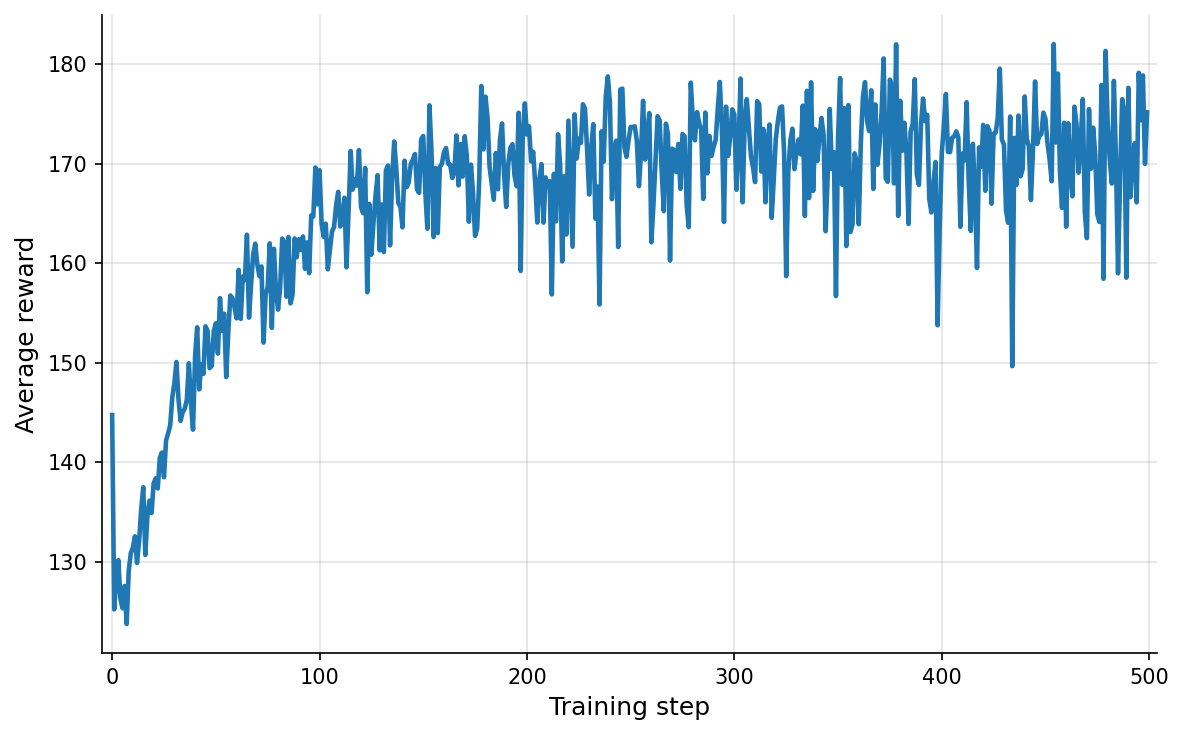

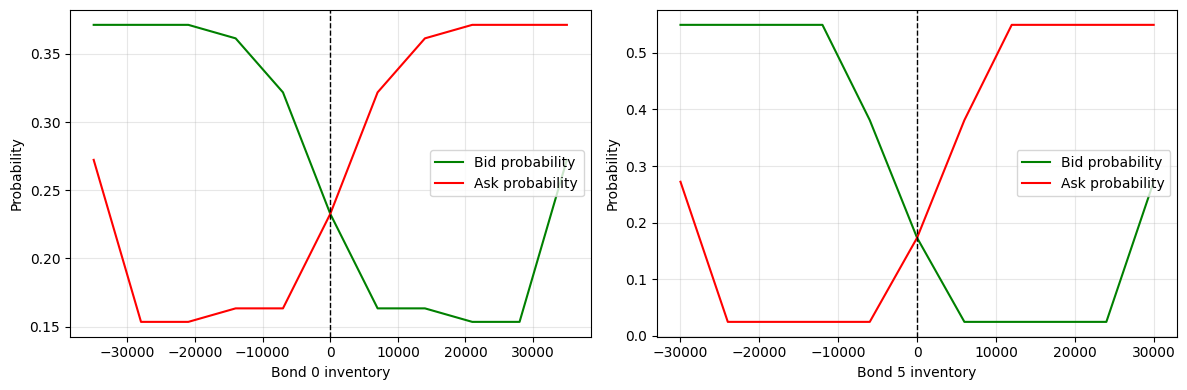

In [ ]:
exp2 = run_experiment(
    selected_bonds=[0, 5],
    nb_steps=500,
    long_horizon=1000,
    nb_short_rollouts=10,
    short_horizon=100,
    critic_lr=5e-8,
    critic_batch_size=70,
    n_epochs_critic=1,
    p_grid_size=101,
    device="cpu",
)

plot_avg_reward(exp2['out']['avg_reward_long'], filename= "avg_reward_[0, 5]_alternative.eps")
plot_actor_tables(exp2)


## Five-bond run

This is the same greedy approximation pushed to a larger basket.  
The policy quality should degrade because each actor still refreshes on a 1D slice while the critic and risk are fully multivariate.


In [ ]:
exp8 = run_experiment(
    selected_bonds=[0, 4, 5, 6, 7],
    nb_steps=3000,
    long_horizon=1000,
    nb_short_rollouts=100,
    short_horizon=100,
    critic_lr=5e-8,
    critic_batch_size=70,
    n_epochs_critic=1,
    p_grid_size=101,
    device="cpu",
)

plot_avg_reward(exp2['out']['avg_reward_long'], filename= "avg_reward_[4, 6, 7, 11, 13]_alternative.eps")
plot_actor_tables(exp8, max_bonds=8)


ValueError: broadcast dimensions too large.